# Analyse exploratoire des données (EDA)

**Mémoire** : *Prédiction d'indicateurs des marchés financiers à partir des données de dépenses publiques ouvertes : une approche par machine learning*

Ce notebook explore le jeu de données mensuel construit par `src/02_build_dataset.py`. Objectifs :

1. Comprendre ce que contient chaque colonne.
2. Vérifier la qualité des données (valeurs manquantes, valeurs aberrantes).
3. Regarder les cibles et les variables budgétaires dans le temps.
4. Mesurer les liens entre dépenses publiques et marchés (corrélations).
5. Vérifier les propriétés statistiques utiles pour la modélisation (stationnarité, autocorrélation).

> **Rappel méthodologique** : les cibles et les variables ont été choisies **avant** de regarder les corrélations. Cette exploration est descriptive : elle ne sert pas à choisir les variables (sinon, *data snooping*).

## 0. Préparation

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

df = pd.read_csv("../data/processed/dataset_monthly.csv", index_col="mois")
df.index = pd.PeriodIndex(df.index, freq="M")
print(f"{df.shape[0]} mois x {df.shape[1]} colonnes, de {df.index[0]} à {df.index[-1]}")

150 mois x 44 colonnes, de 2014-03 à 2026-08


## 1. Aperçu du jeu de données

Chaque **ligne = un mois t**. Les colonnes suivent une convention de nommage :

| Préfixe | Signification | Moment |
|---|---|---|
| `y_` | **cibles** à prédire | variation entre t et t+1 |
| (aucun) | marchés et contrôles | connus à la fin du mois t |
| `b_` | **budget de l'État** | mois t-2 (délai de publication ~5 semaines) |

In [2]:
df.head()

,y_d_spread,y_d_oat,y_cac_ret,y_spread_up,spread_bp,oat_10y,bund_10y,d_spread,d_spread_l1,d_oat,d_oat_l1,cac_ret,cac_ret_l1,vix,d_vix,inflation_yoy,ecb_mro,ecb_dfr,b_solde_12m,b_dep_totales_12m,b_dep_totales_ytd_gap,b_dep_personnel_12m,b_dep_personnel_ytd_gap,b_dep_fonctionnement_12m,b_dep_fonctionnement_ytd_gap,b_dep_charge_dette_12m,b_dep_charge_dette_ytd_gap,b_dep_investissement_12m,b_dep_investissement_ytd_gap,b_dep_intervention_12m,b_dep_intervention_ytd_gap,b_psr_total_12m,b_psr_total_ytd_gap,b_rec_totales_12m,b_rec_totales_ytd_gap,b_rec_fiscales_12m,b_rec_fiscales_ytd_gap,b_rec_is_12m,b_rec_is_ytd_gap,b_rec_tva_12m,b_rec_tva_ytd_gap,b_solde_ytd_diff_yoy,b_part_charge_dette_12m,b_source_month
mois,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-03,-6.792857,-12.0,2.183539,0.0,64.142857,2.15,1.508571,-5.007143,6.740909,-10.0,-13.0,-0.376129,5.817958,14.836667,-0.633333,0.763168,0.25,0.0,-74.783117,299.852211,0.401582,119.803752,0.172973,56.081172,0.136848,43.890464,-2.267756,11.177638,10.763826,66.434878,1.091985,77.312818,-0.915477,298.883080,0.389778,285.172748,0.409412,47.086058,-0.150277,136.673688,0.305409,0.084854,14.637365,2014-01
2014-04,-6.064286,-19.0,0.717114,0.0,57.350000,2.03,1.456500,-6.792857,-5.007143,-12.0,-10.0,2.183539,-0.376129,14.198095,-0.638571,0.839178,0.25,0.0,-73.428387,299.272210,0.208556,119.626520,0.025075,55.931894,-0.129678,43.915965,-2.208372,10.942169,8.843516,66.453259,1.119343,77.751411,-0.346215,300.156919,0.812515,286.379572,0.829094,46.985112,-0.365447,137.096720,0.613031,1.439583,14.674254,2014-02
2014-05,-6.714286,-13.0,-2.140248,0.0,51.285714,1.84,1.327143,-6.064286,-6.792857,-19.0,-12.0,0.717114,2.183539,12.475238,-1.722857,0.826239,0.25,0.0,-71.858642,297.375728,-0.427853,119.498525,-0.082008,54.334058,-3.074255,44.098525,-1.785247,10.945299,8.869583,66.610673,1.353016,77.740041,-0.360892,301.826397,1.361146,288.139131,1.434694,47.406821,0.527358,137.026170,0.561860,3.009328,14.829228,2014-03
2014-06,-0.006211,-15.0,-3.995164,0.0,44.571429,1.71,1.264286,-6.714286,-6.064286,-13.0,-19.0,-2.140248,0.717114,11.541429,-0.933810,0.599850,0.15,-0.1,-72.264358,296.989036,-0.558614,119.584346,-0.010183,54.730447,-2.327732,43.615947,-2.911425,11.348912,12.110548,65.851916,0.216389,77.841902,-0.229564,299.964615,0.748927,286.341858,0.816032,44.646570,-5.622488,137.680464,1.034416,2.603612,14.686046,2014-04
2014-07,0.815735,-15.0,3.177001,1.0,44.565217,1.56,1.114348,-0.006211,-6.714286,-15.0,-13.0,-3.995164,-2.140248,12.296364,0.754935,0.564334,0.15,-0.1,-66.558348,298.177057,-0.157960,119.479048,-0.098323,53.887158,-3.929077,45.366038,1.058601,10.794406,7.595694,66.686227,1.464781,75.755893,-2.989478,304.505764,2.229076,291.363984,2.525627,48.736392,3.241058,137.615294,0.987550,8.309623,15.214463,2014-05


In [3]:
groupes = {
    "Cibles (y_)": [c for c in df if c.startswith("y_")],
    "Marchés et contrôles": [c for c in df if not c.startswith(("y_", "b_"))],
    "Budget (b_)": [c for c in df if c.startswith("b_")],
}
for nom, cols in groupes.items():
    print(f"{nom} — {len(cols)} colonnes :\n   " + ", ".join(cols) + "\n")

Cibles (y_) — 4 colonnes :
   y_d_spread, y_d_oat, y_cac_ret, y_spread_up

Marchés et contrôles — 14 colonnes :
   spread_bp, oat_10y, bund_10y, d_spread, d_spread_l1, d_oat, d_oat_l1, cac_ret, cac_ret_l1, vix, d_vix, inflation_yoy, ecb_mro, ecb_dfr

Budget (b_) — 26 colonnes :
   b_solde_12m, b_dep_totales_12m, b_dep_totales_ytd_gap, b_dep_personnel_12m, b_dep_personnel_ytd_gap, b_dep_fonctionnement_12m, b_dep_fonctionnement_ytd_gap, b_dep_charge_dette_12m, b_dep_charge_dette_ytd_gap, b_dep_investissement_12m, b_dep_investissement_ytd_gap, b_dep_intervention_12m, b_dep_intervention_ytd_gap, b_psr_total_12m, b_psr_total_ytd_gap, b_rec_totales_12m, b_rec_totales_ytd_gap, b_rec_fiscales_12m, b_rec_fiscales_ytd_gap, b_rec_is_12m, b_rec_is_ytd_gap, b_rec_tva_12m, b_rec_tva_ytd_gap, b_solde_ytd_diff_yoy, b_part_charge_dette_12m, b_source_month



## 2. Qualité des données

On vérifie qu'il n'y a pas de trous. La dernière ligne (le mois le plus récent) n'a pas de cible : c'est normal, on ne connaît pas encore le mois suivant.

In [4]:
manquants = df.isna().sum()
print("Valeurs manquantes par colonne :")
print(manquants[manquants > 0] if (manquants > 0).any() else "aucune")

Valeurs manquantes par colonne :
y_d_spread     1
y_d_oat        1
y_cac_ret      1
y_spread_up    1
dtype: int64


In [5]:
# Statistiques descriptives des cibles et de quelques variables clés
cles = ["y_d_spread", "y_d_oat", "y_cac_ret", "spread_bp", "oat_10y", "bund_10y", "vix",
        "inflation_yoy", "b_solde_12m", "b_dep_totales_12m", "b_dep_charge_dette_12m"]
df[cles].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
y_d_spread,149.0,0.12,5.27,-18.08,-3.12,0.14,2.39,20.54
y_d_oat,149.0,1.24,16.99,-54.00,-9.00,-1.00,11.00,72.00
y_cac_ret,149.0,0.53,4.55,-17.21,-2.40,0.75,3.19,20.12
spread_bp,150.0,49.09,15.56,26.41,37.31,44.57,59.55,83.64
oat_10y,150.0,1.41,1.31,-0.34,0.38,0.86,2.89,4.00
bund_10y,150.0,0.92,1.19,-0.65,-0.01,0.47,2.22,3.18
vix,150.0,18.05,6.25,10.13,13.93,16.74,20.08,57.74
inflation_yoy,150.0,1.93,1.94,-0.40,0.60,1.34,2.50,7.29
b_solde_12m,150.0,-117.22,43.54,-193.67,-154.92,-110.18,-75.50,-56.29
b_dep_totales_12m,150.0,373.25,61.66,294.27,317.90,347.90,440.21,465.52


**Contrôle de cohérence** : le solde budgétaire annuel reconstitué (somme des 12 mois de décembre) doit correspondre aux chiffres officiels publiés par l'État (ex. -178,1 Md€ en 2020).

In [6]:
dec = df[df["b_source_month"].str.endswith("-12")][["b_source_month", "b_solde_12m", "b_dep_totales_12m", "b_dep_charge_dette_12m"]]
dec.set_index("b_source_month").round(1).rename(columns={
    "b_solde_12m": "Solde (Md€)", "b_dep_totales_12m": "Dépenses totales (Md€)",
    "b_dep_charge_dette_12m": "Charge de la dette (Md€)"})

,Solde (Md€),Dépenses totales (Md€),Charge de la dette (Md€)
b_source_month,,,
2014-12,-85.6,302.9,43.2
2015-12,-70.5,301.6,42.1
2016-12,-69.1,314.4,41.4
2017-12,-67.7,326.8,41.7
2018-12,-76.0,329.7,41.5
2019-12,-92.7,336.1,40.3
2020-12,-178.1,389.7,36.2
2021-12,-170.7,426.7,38.5
2022-12,-151.4,445.7,51.5


## 3. Les données brutes du budget : pourquoi on les transforme

La DGFiP publie des montants **cumulés depuis janvier**. Ils remontent toute l'année puis retombent à zéro en janvier. On ne peut pas les utiliser tels quels : on les transforme en **flux mensuels** puis en **somme sur 12 mois glissants**, qui n'a plus de saisonnalité.

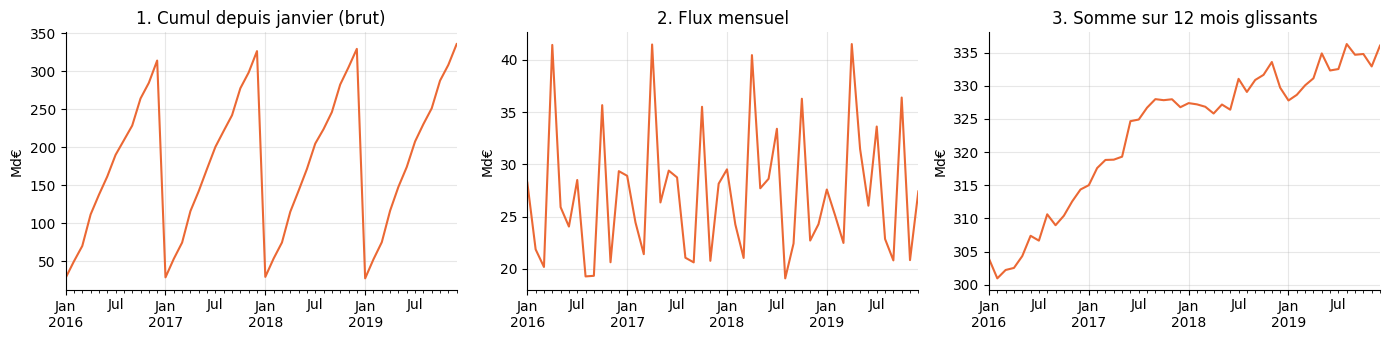

In [7]:
brut = pd.read_csv("../data/raw/budget/Séries longues SMB_DGFiP_2013-2023.csv", sep=";", encoding="utf-16", decimal=",")
ligne = brut[brut["Ligne d'information"].str.strip() == "Total dépenses nettes du budget général"]
dates = [c for c in brut.columns if c.count("/") == 2]
cumul = pd.Series(ligne[dates].values[0] / 1e9, index=pd.to_datetime(dates, format="%d/%m/%Y"))

flux = cumul.diff()
flux[cumul.index.month == 1] = cumul[cumul.index.month == 1]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
cumul["2016":"2019"].plot(ax=axes[0], color=ORANGE, title="1. Cumul depuis janvier (brut)")
flux["2016":"2019"].plot(ax=axes[1], color=ORANGE, title="2. Flux mensuel")
flux.rolling(12).sum()["2016":"2019"].plot(ax=axes[2], color=ORANGE, title="3. Somme sur 12 mois glissants")
for ax in axes: ax.set_ylabel("Md€")
plt.tight_layout()

## 4. Les marchés dans le temps

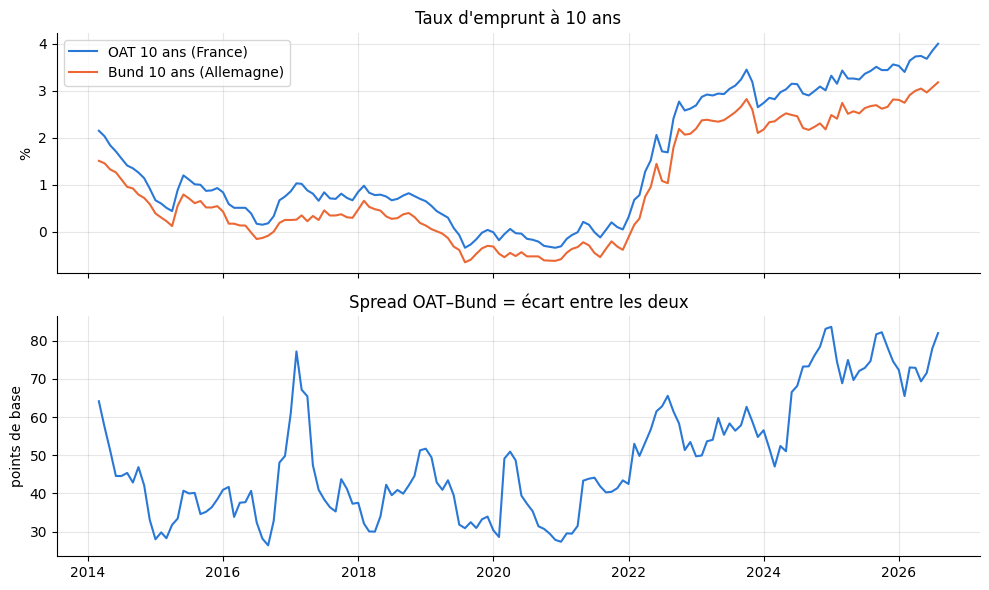

In [8]:
t = df.index.to_timestamp()
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t, df["oat_10y"], color=BLUE, label="OAT 10 ans (France)")
axes[0].plot(t, df["bund_10y"], color=ORANGE, label="Bund 10 ans (Allemagne)")
axes[0].set_ylabel("%"); axes[0].legend(); axes[0].set_title("Taux d'emprunt à 10 ans")
axes[1].plot(t, df["spread_bp"], color=BLUE)
axes[1].set_ylabel("points de base"); axes[1].set_title("Spread OAT–Bund = écart entre les deux")
plt.tight_layout()

**À observer** : les deux taux bougent presque ensemble (politique de la BCE commune). L'écart, lui, a ses propres épisodes : présidentielle 2017, Covid 2020, et une montée continue depuis 2022, accélérée par la dissolution de juin 2024.

## 5. Les trois cibles

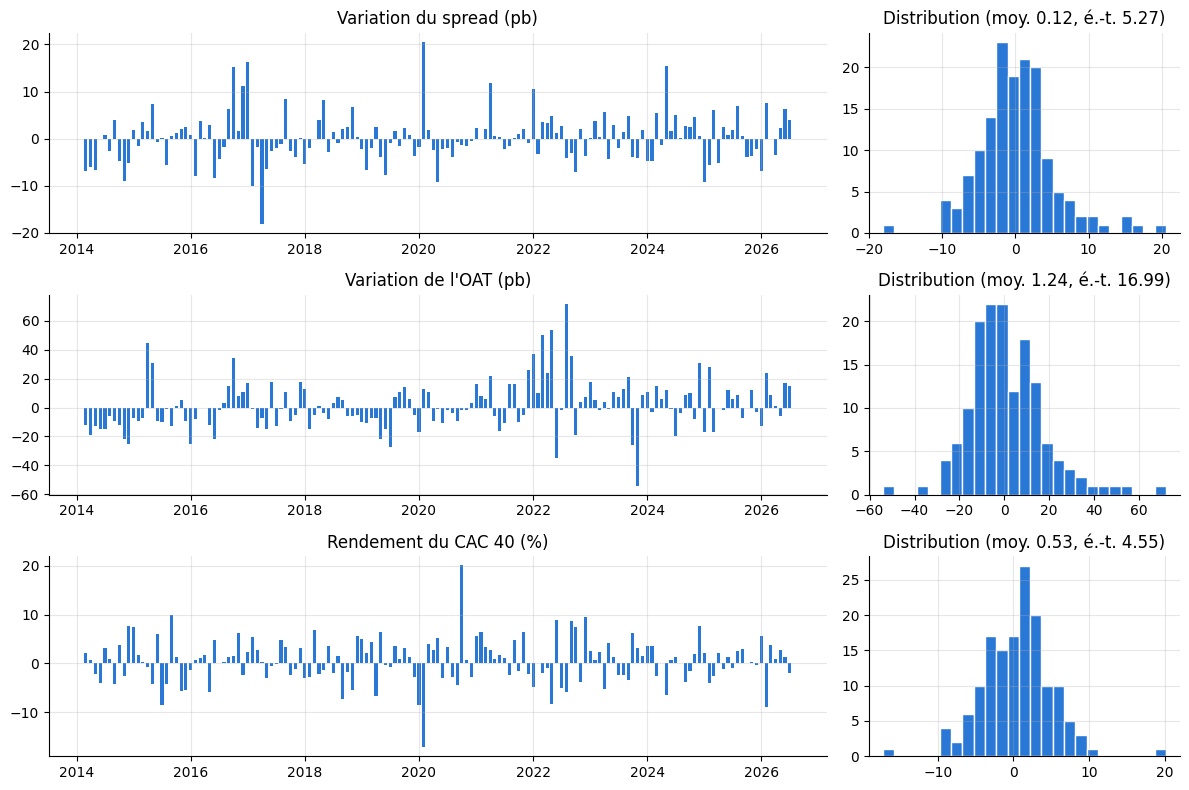

In [9]:
cibles = {"y_d_spread": "Variation du spread (pb)", "y_d_oat": "Variation de l'OAT (pb)", "y_cac_ret": "Rendement du CAC 40 (%)"}
fig, axes = plt.subplots(3, 2, figsize=(12, 8), gridspec_kw={"width_ratios": [2.5, 1]})
for i, (col, lab) in enumerate(cibles.items()):
    y = df[col].dropna()
    axes[i, 0].bar(y.index.to_timestamp(), y, width=20, color=BLUE)
    axes[i, 0].set_title(lab)
    axes[i, 1].hist(y, bins=25, color=BLUE, edgecolor="white")
    axes[i, 1].set_title(f"Distribution (moy. {y.mean():.2f}, é.-t. {y.std():.2f})")
plt.tight_layout()

In [10]:
# Classification : part des mois où le spread monte (= score à battre pour un modèle "toujours hausse")
print(f"Le spread monte dans {df['y_spread_up'].mean():.0%} des mois")

Le spread monte dans 52% des mois


## 6. Les dépenses publiques dans le temps

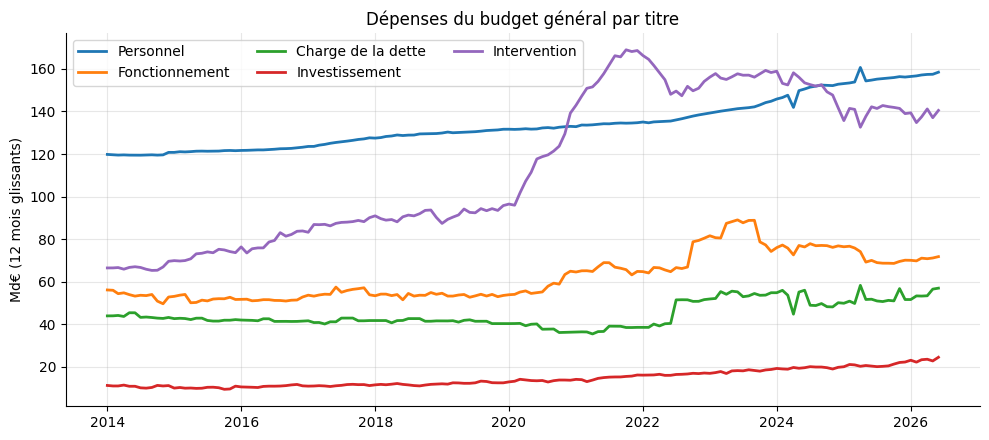

In [11]:
dep = {"b_dep_personnel_12m": "Personnel", "b_dep_fonctionnement_12m": "Fonctionnement",
       "b_dep_charge_dette_12m": "Charge de la dette", "b_dep_investissement_12m": "Investissement",
       "b_dep_intervention_12m": "Intervention"}
t_budget = pd.PeriodIndex(df["b_source_month"], freq="M").to_timestamp()  # mois réel du budget
fig, ax = plt.subplots(figsize=(10, 4.5))
for col, lab in dep.items():
    ax.plot(t_budget, df[col], label=lab, lw=2)
ax.set_ylabel("Md€ (12 mois glissants)"); ax.set_title("Dépenses du budget général par titre")
ax.legend(ncol=3, loc="upper left")
plt.tight_layout()

## 7. Liens entre dépenses publiques et marchés

On calcule la **corrélation de Spearman** (robuste aux valeurs extrêmes) entre chaque variable budgétaire (mois t-2) et chaque cible (mois t+1). Avec 149 mois, une corrélation est significative à 5 % si elle dépasse environ **±0,16**.

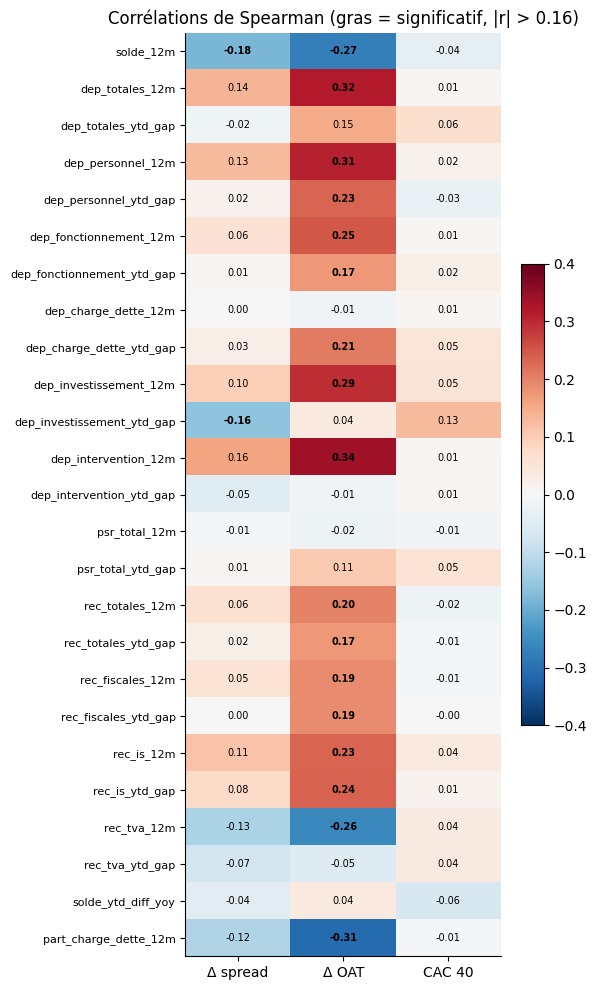

In [12]:
budget_cols = [c for c in df if c.startswith("b_") and c != "b_source_month"]
d = df.dropna(subset=["y_d_spread"])
corr = d[budget_cols + list(cibles)].corr(method="spearman").loc[budget_cols, list(cibles)]
seuil = 1.96 / np.sqrt(len(d))

fig, ax = plt.subplots(figsize=(6, 10))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-0.4, vmax=0.4, aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(["Δ spread", "Δ OAT", "CAC 40"])
ax.set_yticks(range(len(budget_cols))); ax.set_yticklabels([c[2:] for c in budget_cols], fontsize=8)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                fontweight="bold" if abs(v) > seuil else "normal")
ax.grid(False); plt.colorbar(im, ax=ax, shrink=0.5)
ax.set_title(f"Corrélations de Spearman (gras = significatif, |r| > {seuil:.2f})")
plt.tight_layout()

In [13]:
# Les liens les plus forts pour chaque cible
for col, lab in cibles.items():
    top = corr[col].reindex(corr[col].abs().sort_values(ascending=False).index).head(5)
    print(f"\n{lab} :\n{top.round(3).to_string()}")


Variation du spread (pb) :
b_solde_12m                    -0.182
b_dep_investissement_ytd_gap   -0.161
b_dep_intervention_12m          0.158
b_dep_totales_12m               0.137
b_dep_personnel_12m             0.126

Variation de l'OAT (pb) :
b_dep_intervention_12m      0.340
b_dep_totales_12m           0.318
b_dep_personnel_12m         0.309
b_part_charge_dette_12m    -0.308
b_dep_investissement_12m    0.294

Rendement du CAC 40 (%) :
b_dep_investissement_ytd_gap    0.125
b_solde_ytd_diff_yoy           -0.064
b_dep_totales_ytd_gap           0.064
b_psr_total_ytd_gap             0.055
b_dep_investissement_12m        0.050


### Piège n° 1 : les variables en niveau (`_12m`)

Les variables `_12m` (somme sur 12 mois, en Md€) sont des **niveaux** qui augmentent presque tout le temps (les dépenses croissent avec l'inflation et la dette). Depuis 2022, les taux montent aussi. Deux séries qui montent en même temps sont corrélées **même sans aucun lien réel** : c'est une *corrélation fallacieuse* (spurious correlation). Le test ADF plus bas le confirme : ces niveaux ne sont pas stationnaires.

**Règle pour la modélisation** : on utilise les variables `_ytd_gap` (écart sur un an, stationnaires), pas les niveaux `_12m`.

### Piège n° 2 : l'inflation

Plusieurs dépenses semblent liées à la variation de l'OAT. Mais en 2022-2023, l'**inflation** a fait monter **en même temps** les taux (la BCE a relevé ses taux) et certaines dépenses (salaires, charge de la dette indexée sur l'inflation). On contrôle donc l'effet de l'inflation avec une **corrélation partielle**.

In [14]:
def corr_partielle(data, x, y, controles):
    r = data[[x, y] + controles].rank()
    Z = np.column_stack([np.ones(len(r))] + [r[c] for c in controles])
    res_x = r[x] - Z @ np.linalg.lstsq(Z, r[x], rcond=None)[0]
    res_y = r[y] - Z @ np.linalg.lstsq(Z, r[y], rcond=None)[0]
    return np.corrcoef(res_x, res_y)[0, 1]

lignes = []
for f in ["b_dep_personnel_ytd_gap", "b_dep_fonctionnement_ytd_gap", "b_dep_charge_dette_ytd_gap"]:
    lignes.append({"variable": f,
                   "corrélation brute": d[f].corr(d["y_d_oat"], method="spearman"),
                   "corrélation partielle (inflation, ΔOAT passée)": corr_partielle(d, f, "y_d_oat", ["inflation_yoy", "d_oat"])})
pd.DataFrame(lignes).set_index("variable").round(2)

,corrélation brute,"corrélation partielle (inflation, ΔOAT passée)"
variable,,
b_dep_personnel_ytd_gap,0.23,0.13
b_dep_fonctionnement_ytd_gap,0.17,0.08
b_dep_charge_dette_ytd_gap,0.21,0.07


**Lecture** : une fois l'inflation contrôlée, les corrélations baissent nettement et deviennent non significatives. Une grande partie du lien apparent venait de l'inflation, pas des dépenses. C'est pourquoi l'inflation reste dans le modèle « contrôles seuls ».

## 8. Propriétés statistiques pour la modélisation

**Stationnarité (test ADF)** : une série stationnaire a une moyenne et une variance stables dans le temps. Les modèles de prévision supposent en général des cibles stationnaires. Si p-value < 0,05, la série est stationnaire.

In [15]:
res = []
for col in list(cibles) + ["spread_bp", "oat_10y", "b_solde_12m", "b_dep_totales_12m", "b_dep_charge_dette_12m", "b_dep_totales_ytd_gap", "b_dep_charge_dette_ytd_gap"]:
    y = df[col].dropna()
    res.append({"variable": col, "p-value ADF": adfuller(y, autolag="AIC")[1]})
adf = pd.DataFrame(res).set_index("variable")
adf["stationnaire ?"] = np.where(adf["p-value ADF"] < 0.05, "oui", "non")
adf.round(3)

,p-value ADF,stationnaire ?
variable,,
y_d_spread,0.000,oui
y_d_oat,0.000,oui
y_cac_ret,0.000,oui
spread_bp,0.310,non
oat_10y,0.937,non
b_solde_12m,0.734,non
b_dep_totales_12m,0.896,non
b_dep_charge_dette_12m,0.902,non
b_dep_totales_ytd_gap,0.057,non


**Lecture** : les trois cibles (des variations) sont clairement stationnaires ; les niveaux (spread, OAT, solde, dépenses `_12m`) ne le sont pas du tout (p > 0,7). Les variables `_ytd_gap` sont nettement plus proches de la stationnarité (p entre 0,01 et 0,06) : c'est ce qui justifie de prédire des **variations** et de privilégier les `_ytd_gap` comme variables explicatives.

**Autocorrélation** : est-ce que la variation d'un mois ressemble à celle du mois précédent ? Si oui, la valeur passée de la cible est un bon prédicteur (c'est ce que trouvent Bouillot et al., 2025).

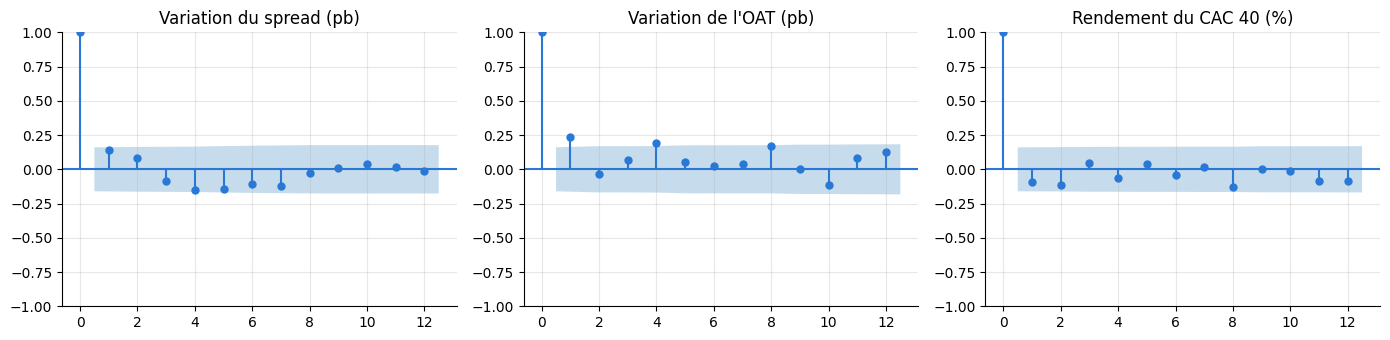

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, (col, lab) in zip(axes, cibles.items()):
    plot_acf(df[col].dropna(), lags=12, ax=ax, title=lab, color=BLUE, vlines_kwargs={"colors": BLUE})
plt.tight_layout()

## 9. Conclusions de l'exploration

1. **Données propres** : 149 mois exploitables (mars 2014 – juillet 2026), aucune valeur manquante, soldes annuels conformes aux chiffres officiels.
2. **Cibles stationnaires** : on modélise bien des variations.
3. **Variables en niveau à écarter** : les `_12m` créent des corrélations fallacieuses (tendances communes).
4. **Signal budgétaire faible** : pour le spread, seules les dépenses d'investissement sont à la limite de la significativité ; pour le CAC 40, rien.
5. **Piège de l'inflation** : les liens apparents entre dépenses et taux OAT viennent en grande partie de l'inflation de 2022-2023.
6. **Autocorrélation** : la variation passée aide un peu à prévoir la suivante, surtout pour l'OAT → elle doit figurer dans tous les modèles.

**Conséquence pour la suite** : il faut s'attendre à un apport modeste des dépenses publiques. Le chapitre 3 le testera rigoureusement, en comparant un modèle avec et sans dépenses, en validation glissante.